/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2413/1795166444.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



BELL STATE MEASUREMENT IN HADAMARD BASIS

QUANTUM CIRCUIT
---------------------------------------------------------------------------
     ┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ H ├
     └───┘┌─┴─┐├───┤
q_1: ─────┤ X ├┤ H ├
          └───┘└───┘

THEORETICAL PROBABILITIES
---------------------------------------------------------------------------
++ : 0.5000
+- : 0.0000
-+ : 0.0000
-- : 0.5000

1024-SHOT RESULTS
---------------------------------------------------------------------------
++ : 515
+- : 0
-+ : 0
-- : 509

CORRELATION ANALYSIS
---------------------------------------------------------------------------
Same results (+ + or - -) : 1024
Different results (+ - or - +) : 0
Same-result percentage : 100.00%
Different-result percentage : 0.00%

RESULT : Perfect correlation in the Hadamard basis.


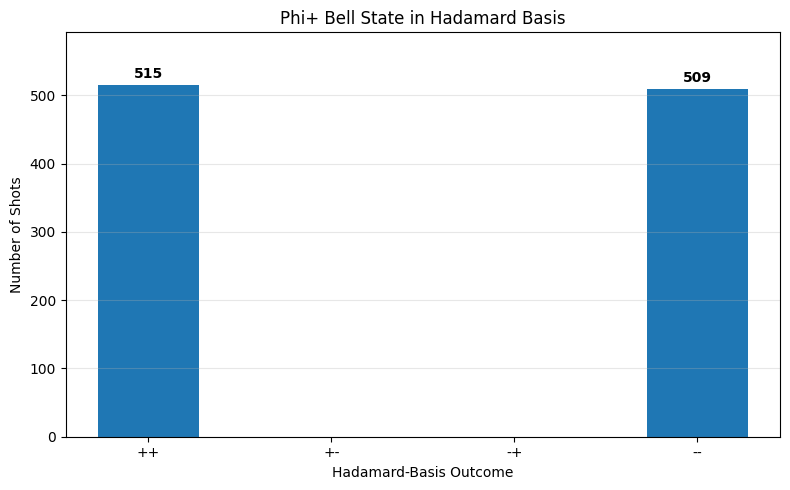

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

qc = QuantumCircuit(2)

# Create Phi+ Bell state
qc.h(0)
qc.cx(0, 1)

# Convert Hadamard basis measurement
# into computational basis measurement
qc.h(0)
qc.h(1)

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

rng = np.random.default_rng(SEED)

samples = rng.choice(
    np.arange(4),
    size=SHOTS,
    p=probabilities
)

counts = np.bincount(
    samples,
    minlength=4
)

labels = [
    "++",
    "+-",
    "-+",
    "--"
]

print("\nBELL STATE MEASUREMENT IN HADAMARD BASIS")
print("=" * 75)

print("\nQUANTUM CIRCUIT")
print("-" * 75)
print(qc.draw())

print("\nTHEORETICAL PROBABILITIES")
print("-" * 75)

for label, probability in zip(
    labels,
    probabilities
):
    print(
        f"{label} : {probability:.4f}"
    )

print("\n1024-SHOT RESULTS")
print("-" * 75)

for label, count in zip(
    labels,
    counts
):
    print(
        f"{label} : {count}"
    )

same_basis_count = counts[0] + counts[3]
different_basis_count = counts[1] + counts[2]

print("\nCORRELATION ANALYSIS")
print("-" * 75)

print(
    f"Same results (+ + or - -) : "
    f"{same_basis_count}"
)

print(
    f"Different results (+ - or - +) : "
    f"{different_basis_count}"
)

print(
    f"Same-result percentage : "
    f"{same_basis_count / SHOTS * 100:.2f}%"
)

print(
    f"Different-result percentage : "
    f"{different_basis_count / SHOTS * 100:.2f}%"
)

if different_basis_count == 0:

    print(
        "\nRESULT : Perfect correlation in "
        "the Hadamard basis."
    )

else:

    print(
        "\nRESULT : Small statistical variation "
        "may be present."
    )

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    labels,
    counts,
    width=0.55
)

ax.set_title(
    "Phi+ Bell State in Hadamard Basis"
)

ax.set_xlabel(
    "Hadamard-Basis Outcome"
)

ax.set_ylabel(
    "Number of Shots"
)

ax.set_ylim(
    0,
    max(counts) * 1.15
)

for bar, value in zip(
    bars,
    counts
):

    if value > 0:

        ax.text(
            bar.get_x()
            + bar.get_width() / 2,
            value + 10,
            str(value),
            ha="center",
            fontweight="bold"
        )

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()